# Mass mapping with uncertainty quantification
*Notebook reproducing the results from Leterme, H. Leterme, A. Tersenov, J. Fadili, and J.-L. Starck, “A plug-and-play approach with fast uncertainty quantification for weak lensing mass mapping,” Oct. 2025.*

In [1]:
%config InlineBackend.figure_format = 'svg'
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch

import wlmmuq as wl
import wlmmuq.data.kappatng as wlktng
import wlmmuq.data.cosmos as wlcosmos
import wlmmuq.models.cqr as wlcqr
import wlmmuq.utils as wlutils

Configuration file found in /feynman/home/dap/lcs/hl285110/.config/wlmmuq


/feynman/home/dap/lcs/hl285110/.conda/envs/wlmmuq/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/feynman/home/dap/lcs/hl285110/.conda/envs/wlmmuq/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignme

In [3]:
model_dir = wl.MODEL_DIR
path_to_test_dataset = wl.PATH_TO_TEST_DATASET
path_to_ps = wl.PATH_TO_PS
path_to_std_noise = wl.PATH_TO_STD_NOISE
path_to_mask = wl.PATH_TO_MASK
path_to_extent = wl.PATH_TO_EXTENT

In [4]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [5]:
nimgs_test = 512
batch_size = 32
imgsize = 384

# For imshow
imgsize_imshow = 304
vmin = -0.04
vmax = 0.29
vmax_sqdiff = 1e-2
vmax_bounds = 0.23
om = 1
idx = 0 # Index of the image to display
confidence = 2 # 2-sigma confidence
nimgs_calib = 1024

## Load noise standard deviation and noise

Diagonal elements of $\Sigma$ and masked pixels.

The noise standard deviation has been obtained by binning the COSMOS shape galaxy catalog (https://www.aanda.org/articles/aa/abs/2010/08/aa13577-09/aa13577-09.html) at a resolution of $0.29$ arcmin per pixel, to match the $\kappa$-TNG dataset of simulated convergence maps (https://academic.oup.com/mnras/article/502/4/5593/6133466).

The noise standard deviation is given, for each pixel $k$, by 
\begin{equation}
    \sigma_k = \frac{\sigma_{\text{ell}}}{\sqrt{N_k}},
\end{equation}
where $\sigma_{\text{ell}}$ denotes the intrinsic shape dispersion of galaxies, and $N_k$ denotes the number of measured galaxies.

In [6]:
cat_cosmos_bright, _ = wlcosmos.cosmos_catalog()
cat_cosmos_bright = wlcosmos.filter_by_redshifts(cat_cosmos_bright, wlktng.MAX_Z)
data_dict = wlktng.get_data_from_cosmos_ktng(cat_cosmos_bright, imgsize)

extent = torch.tensor(data_dict["extent"]) # For imshow
shapedisp = data_dict["shapedisp"] # Intrinsic shape dispersion
ngal = data_dict["ngal"] # Number of galaxies per pixel
mask = data_dict["mask"] # Mask

std_noise = wlutils.get_std_noise(ngal, shapedisp, std_noise_mask=0) # Noise standard deviation

In [7]:
# Alternatively, load precomputed data (uncomment the following lines)
# std_noise = torch.load(path_to_std_noise)
# mask = torch.load(path_to_mask)
# extent = torch.load(path_to_extent)

In [8]:
ra, dec = np.array(wlcosmos.COSMOS_VERTICES).T # Survey boundaries

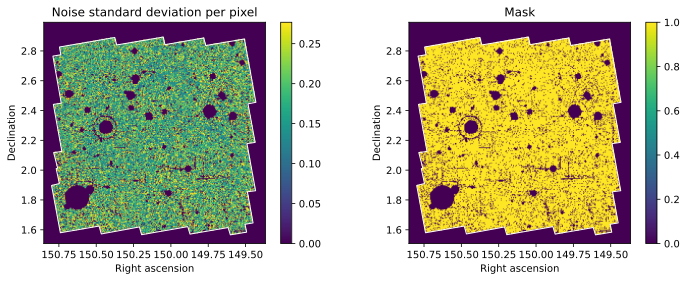

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(121)
wlutils.skyshow(
    std_noise, imgsize=imgsize_imshow,
    boundaries=(ra, dec), extent=extent
)
plt.title("Noise standard deviation per pixel")
plt.subplot(122)
wlutils.skyshow(
    mask, imgsize=imgsize_imshow,
    boundaries=(ra, dec), extent=extent
)
plt.title("Mask")
plt.show()

## Run mass mapping with CQR

Execute the following bash commands from the root of the repository.
Please refer to the documentation of each Python script for more information.

### Wiener

```bash
python scripts/wiener.py --cqr -w 8 --save-tensors -o results_wiener_cqr --seed 42 -v
```

### MCALens

```bash
python scripts/mcalens.py -thresh 4.5 -alph 0.5 -i 16 --cqr -w 8 --save-tensors -o results_mcalens_starlet-detection-threshold_4.5_niter_16_cqr --seed 42 -v
```

### DeepMass

```bash
python scripts/deepmass.py -c deepmass_arch_UNetPreproc_mode-preproc_wiener_nepochs_20 -a UNetPreproc -m wiener -t 20250613_142121 -e 20 -uq -t0 20250917_153127 -e0 100 --cqr --find-optimal-hyperparam-precalib -w 8 --save-tensors -o results_deepmass_epoch_20_epoch-uq_100_cqr --seed 42 -v
```

### PnPMass

```bash
python scripts/pnpmass.py -c denoiser_arch_SUNetNoiseAware_scale_0.2_scale-min_0.0_batch-size_16_nepochs_100_learning-rate_1e-3 -a SUNetNoiseAware -t 20250613_143319 -uq -t0 20250903_164013 -i 8 --cqr --find-optimal-hyperparam-precalib -w 8 --save-tensors -o results_pnpmass_niter_8_cqr --seed 42 -v
```

### PnPMass (residual version)

```bash
python scripts/pnpmass.py -c denoiser_arch_SUNetNoiseAware_nongaussian_scale_0.2_scale-min_0.0_batch-size_16_nepochs_100_learning-rate_1e-3 -a SUNetNoiseAware -t 20250716_170944 --mode residual -uq -t0 20250903_164205 -i 8 --cqr --find-optimal-hyperparam-precalib -w 8 --save-tensors -o results_pnpmass_mode_residual_niter_8_cqr --seed 42 -v
```

## Load results

In [10]:
listof_configname = [
    "Wiener",
    "MCALens",
    "DeepMass",
    "PnPMass",
    "PnPMass (res.)",
]

listof_dirname = [
    "wiener",
    "mcalens",
    "deepmass_arch_UNetPreproc_mode-preproc_wiener_nepochs_20",
    (
        "denoiser_arch_SUNetNoiseAware_scale_0.2_scale-min_0.0_"
        "batch-size_16_nepochs_100_learning-rate_1e-3"
    ),
    (
        "denoiser_arch_SUNetNoiseAware_nongaussian_scale_0.2_scale-min_0.0_"
        "batch-size_16_nepochs_100_learning-rate_1e-3"
    ),
]

listof_timestamp_pe = [
    None, None,
    "20250613_142121",
    "20250613_143319",
    "20250716_170944",
]
listof_nepochs_pe = [
    None, None, 20, 100, 100
]

listof_timestamp_uq = [
    None, None,
    "20250917_153127",
    "20250903_164013",
    "20250903_164205",
]
listof_nepochs_uq = [
    None, None, 100, 100, 100
]

In [11]:
listof_filename_results = [
    (
        "results_wiener_cqr_20251017_150003.pt"
    ),
    (
        "results_mcalens_starlet-detection-threshold_4.5_"
        "niter_16_cqr_step-size_0.088_20251017_150548.pt"
    ),
    (
        "results_deepmass_epoch_20_epoch-uq_100_cqr_20251017_150702.pt"
    ),
    (
        "results_pnpmass/results_pnpmass_"
        "niter_8_cqr_step-size_0.176_20251017_151012.pt"
    ),
    (
        "results_pnpmass/results_pnpmass_mode_residual_"
        "niter_8_cqr_step-size_0.176_20251017_151138.pt"
    ),
]

In [12]:
listof_path_to_saved_results = [
    os.path.join(
        model_dir,
        dirname,
        filename
    ) for dirname, filename in zip(listof_dirname, listof_filename_results)
]
listof_results = [
    torch.load(path_to_saved_results, map_location="cpu", weights_only=False) \
        for path_to_saved_results in listof_path_to_saved_results
]

In [13]:
listof_nrmse = []
listof_l2norm = []
for configname, results in zip(listof_configname, listof_results):
    rmse = results["rmse"]
    try:
        l2norm = results["l2norm"]
    except KeyError:
        l2norm = results["rl2norm"]
    if rmse.ndim > 1: # Shape = (nimgs, niter)
        rmse = rmse[:, -1] # Last iteration
    nrmse = rmse / l2norm
    listof_nrmse.append(nrmse)
    listof_l2norm.append(l2norm)
    print(f"{configname}:")
    print(f"\tRMSE = {rmse.mean():.3e} +/- {rmse.std():.3e}")
    print(f"\tNRMSE = {nrmse.mean():.3e} +/- {nrmse.std():.3e}")

Wiener:
	RMSE = 1.820e-02 +/- 1.139e-03
	NRMSE = 8.863e-01 +/- 3.449e-02
MCALens:
	RMSE = 1.792e-02 +/- 9.505e-04
	NRMSE = 8.740e-01 +/- 4.446e-02
DeepMass:
	RMSE = 1.748e-02 +/- 9.044e-04
	NRMSE = 8.528e-01 +/- 4.795e-02
PnPMass:
	RMSE = 1.772e-02 +/- 8.817e-04
	NRMSE = 8.643e-01 +/- 4.975e-02
PnPMass (res.):
	RMSE = 1.758e-02 +/- 8.953e-04
	NRMSE = 8.575e-01 +/- 4.862e-02


In [14]:
for configname, results in zip(listof_configname, listof_results):
    print(f"{configname}:")
    print(f"\tInference time = {results['inference_time']:.1f} secs")
    print(f"\tCalibration time = {results['calibration_time']:.1f} secs")

Wiener:
	Inference time = 7.7 secs
	Calibration time = 15.0 secs
MCALens:
	Inference time = 12.4 secs
	Calibration time = 22.3 secs
DeepMass:
	Inference time = 9.0 secs
	Calibration time = 19.5 secs
PnPMass:
	Inference time = 23.4 secs
	Calibration time = 43.5 secs
PnPMass (res.):
	Inference time = 25.4 secs
	Calibration time = 49.9 secs


## Visualize reconstructions and bounds

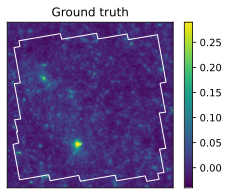

In [15]:
plt.figure(figsize=(4, 3))
wlutils.skyshow(
    listof_results[0]["kappa_true"][idx, 0],
    title="Ground truth",
    vmin=vmin, vmax=vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.show()

In [16]:
listof_skyshow_pred_bounds = [
    wlutils.KappamapVisualizerCompact(
        kappa_true=results["kappa_true"][idx, 0],
        kappa_pred=results["kappa_pred"][idx, 0],
        var=results["var"][idx, 0],
        res_pred=results["uq"]["res_cqr"][idx, 0],
        extent=extent, boundaries=(ra, dec),
        mask=mask, imgsize=imgsize_imshow,
        vmin=vmin, vmax=vmax, vmax_sqdiff=vmax_sqdiff,
        vmax_bounds=vmax_bounds,
        plot_colorbar=True,
    ) for results in listof_results
]

The images below represent, for each mass mapping method, a point estimate, a pre-calibration standard deviation estimate, and post-calibration lower- and upper-bounds. 

### Wiener

Pre-calibration error bars are set to $0$.

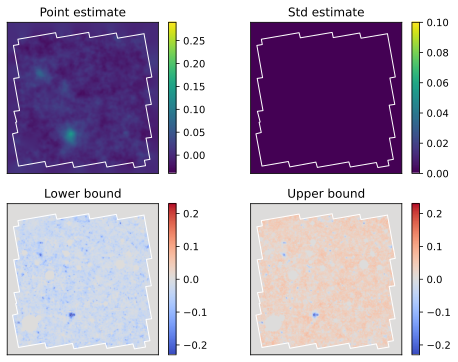

In [17]:
listof_skyshow_pred_bounds[0].visualize(showstd=True)

### MCALens

Pre-calibration error bars are set to $0$.

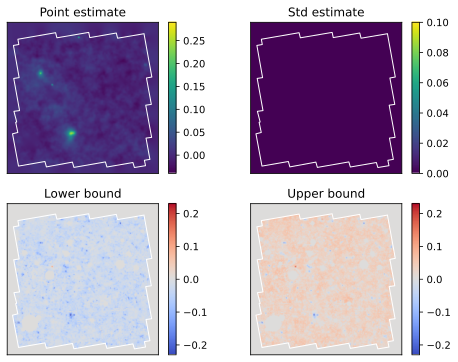

In [18]:
listof_skyshow_pred_bounds[1].visualize(showstd=True)

### DeepMass

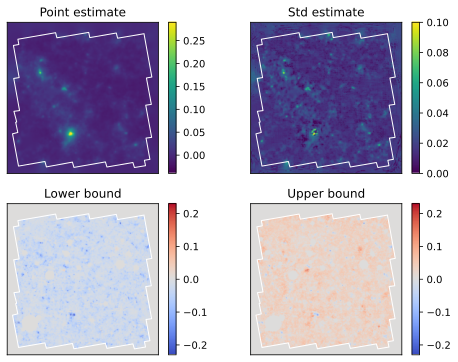

In [19]:
listof_skyshow_pred_bounds[2].visualize(showstd=True)

### PnPMass

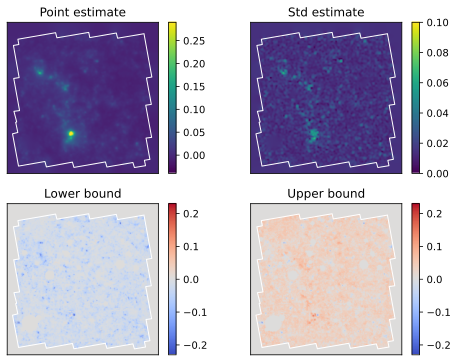

In [20]:
listof_skyshow_pred_bounds[3].visualize(showstd=True)

### PnPMass (residual version)

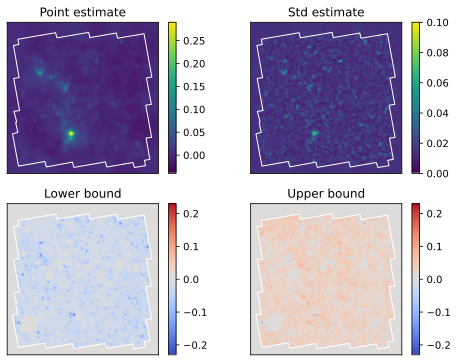

In [21]:
listof_skyshow_pred_bounds[4].visualize(showstd=True)

## Plot statistics

In [22]:
listof_err = []
listof_err_cqr = []
listof_npredinterv = []
listof_npredinterv_cqr = []

for results, l2norm in zip(listof_results, listof_l2norm):
    err = results["uq"]["err"]
    predinterv = results["uq"]["predinterv"]
    err_cqr = results["uq"]["err_cqr"]
    predinterv_cqr = results["uq"]["predinterv_cqr"]

    listof_err.append(err)
    listof_err_cqr.append(err_cqr)
    listof_npredinterv.append(predinterv / l2norm)
    listof_npredinterv_cqr.append(predinterv_cqr / l2norm)

nrmse = torch.stack(listof_nrmse, dim=1)
err = torch.stack(listof_err, dim=1)
err_cqr = torch.stack(listof_err_cqr, dim=1)
npredinterv = torch.stack(listof_npredinterv, dim=1)
npredinterv_cqr = torch.stack(listof_npredinterv_cqr, dim=1)

mean_nrmse = nrmse.mean(dim=0)
mean_err = err.mean(dim=0)
mean_err_cqr = err_cqr.mean(dim=0)
mean_npredinterv = npredinterv.mean(dim=0)
mean_npredinterv_cqr = npredinterv_cqr.mean(dim=0)

std_nrmse = nrmse.std(dim=0)
std_err = err.std(dim=0)
std_err_cqr = err_cqr.std(dim=0)
std_npredinterv = npredinterv.std(dim=0)
std_npredinterv_cqr = npredinterv_cqr.std(dim=0)

In [23]:
idx_plot = [0, 1, 2, 3, 4]

x_offsets = 5 * [5e-4]
y_offsets = 5 * [3e-4]
positions = [
    "left",
    "left",
    "left",
    "left",
    "left",
]
weights = [
    "normal",
    "normal",
    "normal",
    "normal",
    "normal",
]

alpha = wlutils.get_alpha_from_confidence(confidence)

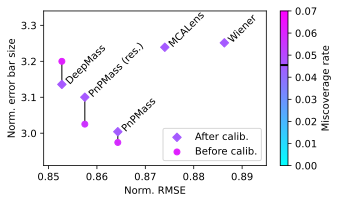

In [24]:
colormap = cm.cool
norm = mcolors.Normalize(vmin=0.0, vmax=0.07)

plt.figure(figsize=(5, 2.8))

plt.scatter(
    mean_nrmse[idx_plot], mean_npredinterv_cqr[idx_plot],
    marker="D", c=mean_err_cqr[idx_plot],
    cmap=colormap, norm=norm, label="After calib.", zorder=2
)
# Array of booleans. Do not use `predinterv is not None` as it returns False
mask_plot = mean_npredinterv[idx_plot] > 0
sc = plt.scatter(
    mean_nrmse[idx_plot][mask_plot], mean_npredinterv[idx_plot][mask_plot],
    marker="o", c=mean_err[idx_plot][mask_plot],
    cmap=colormap, norm=norm, label="Before calib.", zorder=2
)

plt.vlines(
    mean_nrmse[idx_plot][mask_plot], ymin=mean_npredinterv[idx_plot][mask_plot],
    ymax=mean_npredinterv_cqr[idx_plot][mask_plot], colors='k', linewidth=1., zorder=1
)

for x, y, x_off, y_off, method, pos, wgt in zip(
        mean_nrmse[idx_plot], mean_npredinterv_cqr[idx_plot], x_offsets, y_offsets,
        [listof_configname[i] for i in idx_plot], positions, weights
):
    plt.text(x + x_off, y + y_off, method, ha=pos, weight=wgt, rotation=45)

plt.ylim(bottom=2.91, top=3.34)
plt.xlim(left=0.849, right=0.895)
plt.xlabel("Norm. RMSE")
plt.ylabel("Norm. error bar size")
plt.legend(loc="lower right")
cbar = plt.colorbar(sc)
cbar.ax.hlines(alpha, xmin=0, xmax=1, color='black', linewidth=2, label="Target")
cbar.set_label(f"Miscoverage rate")

plt.show()

In [25]:
listof_mean_err_both = [
    [mean, mean_cqr] for mean, mean_cqr in zip(mean_err, mean_err_cqr)
]
listof_std_err_both = [
    [std, std_cqr] for std, std_cqr in zip(std_err, std_err_cqr)
]

In [26]:
xticklabels = ['Before calibration', 'After calibration']
lower_bound_proba, upper_bound_proba = wlcqr.AddCQR(
    alpha, imgsize
).get_bounds_proba(nimgs_calib)

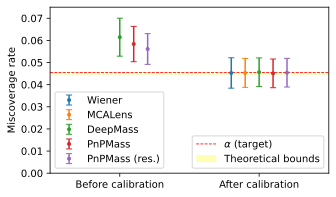

In [27]:
wlutils.plot_means_errs(
    listof_mean_err_both, listof_std_err_both,
    listof_configname, xticklabels=xticklabels, rotation_xticklabels=0,
    ylabel=r"Miscoverage rate", alpha=alpha,
    drawbounds=True, y_lower=lower_bound_proba, y_upper=upper_bound_proba,
    offset=0.1,
    ymin=0.0,
    ymax=0.075,
    figsize=(5, 3), logscale=False,
    args_legend_main={"loc": "lower left"}, args_legend_other={"loc": "lower right"}
)